<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/ASI_MarketRegime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade yfinance
!pip install scipy==1.16.2
!pip install hurst -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 43.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


## install libraries

In [3]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
from datetime import datetime
import time
import random
import requests

import matplotlib.pyplot as plt
from hurst import compute_Hc

from dataclasses import dataclass, field
from typing import Optional
import warnings
warnings.filterwarnings("ignore")
# ensure reproducibility
random.seed(42)
print("Libraries Installed!")

1.4.1
Libraries Installed!


Calculating rolling Hurst...
Progress: 2700/2744 | Valid: 2551
Finished! Valid Hurst values: 2594/2594

Last 10 Days - Hurst, Alpha, K_Alpha, Regime & Adaptive EMAs
             Hurst   Alpha  K_Alpha                        Regime  \
2026-06-03  0.8635  0.2730   1.5905  Trending — Momentum Favoured   
2026-06-04  0.8692  0.2615   1.6077  Trending — Momentum Favoured   
2026-06-05  0.8846  0.2309   1.6537  Trending — Momentum Favoured   
2026-06-08  0.8817  0.2366   1.6450  Trending — Momentum Favoured   
2026-06-09  0.8772  0.2455   1.6317  Trending — Momentum Favoured   
2026-06-10  0.8758  0.2483   1.6275  Trending — Momentum Favoured   
2026-06-11  0.8599  0.2802   1.5797  Trending — Momentum Favoured   
2026-06-15  0.8576  0.2847   1.5729  Trending — Momentum Favoured   
2026-06-16  0.8606  0.2788   1.5818  Trending — Momentum Favoured   
2026-06-17  0.8936  0.2129   1.6807  Trending — Momentum Favoured   

            Fast_EMA_Len  Slow_EMA_Len  
2026-06-03            13          

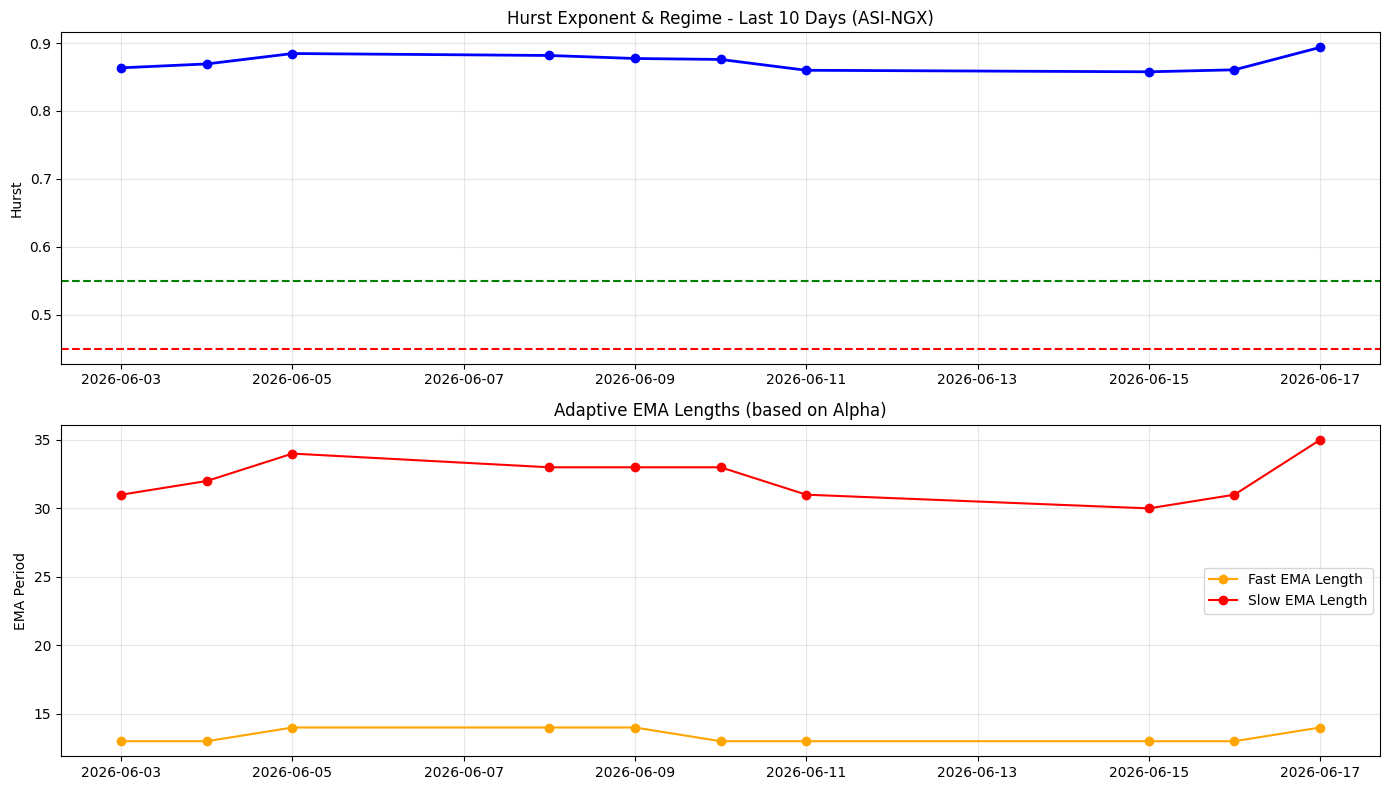

In [15]:

def get_prices():
     return (
        pd.read_csv('asi_data.csv')
        .assign(time=lambda x: pd.to_datetime(x["time"]))
        [["time", "close"]]
        .dropna()
        .set_index("time")
    )

def hurst_exponent(ts):
    ts = np.asarray(ts, dtype=float)
    if len(ts) < 100:
        return np.nan
    try:
        H, _, _ = compute_Hc(ts, kind="price", simplified=True)
        return H
    except:
        return np.nan

def get_regime(h):
    if np.isnan(h):
        return "Unknown"
    elif h > 0.55:
        return "Trending — Momentum Favoured"
    elif h < 0.45:
        return "Mean Reverting — Counter-trend Favoured"
    else:
        return "Random Walk — Reduce Size"

# ====================== NEW FUNCTIONS ======================
def ema_length(alpha, n_min, n_max, k=2):
    """Convert market memory alpha into EMA length"""
    return n_min + (n_max - n_min) * (1 - alpha) ** k

def adaptive_ema_lengths(alpha):
    """Returns fast and slow EMA lengths"""
    fast = ema_length(alpha, n_min=5, n_max=20, k=2)
    slow = ema_length(alpha, n_min=10, n_max=50, k=2)
    return int(round(fast)), int(round(slow))

# ====================== ROLLING HURST ======================
def rolling_hurst(prices, window=150):
    hurst_vals = []
    dates = []
    valid = 0

    print("Calculating rolling Hurst...")

    for i in range(window, len(prices)):
        chunk = prices.iloc[i-window:i].values
        h = hurst_exponent(chunk)
        hurst_vals.append(h)
        dates.append(prices.index[i])

        if not np.isnan(h):
            valid += 1

        if i % 100 == 0:
            print(f"Progress: {i}/{len(prices)} | Valid: {valid}", end="\r")

    H = pd.Series(hurst_vals, index=dates, name="Hurst")
    print(f"\nFinished! Valid Hurst values: {valid}/{len(H)}")
    return H


# ====================== RUN ======================

prices = get_prices()

H = rolling_hurst(prices, window=150)
alpha = np.clip(2 - 2 * H, 0, 1)
k_alpha = 0.5 + 1.5*(1-alpha)

# Create main dataframe
df = pd.DataFrame({
    "Hurst": H,
    "Alpha": alpha,
    "K_Alpha": k_alpha,
    "Regime": H.apply(get_regime)
})

# Add Adaptive EMA Lengths
df['Fast_EMA_Len'], df['Slow_EMA_Len'] = zip(*df['Alpha'].apply(adaptive_ema_lengths))

# Calculate actual EMAs using adaptive lengths (using latest Alpha for simplicity)
latest_alpha = df['Alpha'].iloc[-1]
latest_Kalpha = df['K_Alpha'].iloc[-1]
fast_len, slow_len = adaptive_ema_lengths(latest_alpha)

#latest_Kalpha = 1
#fast_len, slow_len = 8, 15

df['Fast_EMA'] = prices.ewm(span=fast_len, adjust=False).mean()
df['Slow_EMA'] = prices.ewm(span=slow_len, adjust=False).mean()

# Last 10 days
last10 = df.dropna().tail(10)

print("\n" + "="*100)
print("Last 10 Days - Hurst, Alpha, K_Alpha, Regime & Adaptive EMAs")
print(last10[['Hurst', 'Alpha','K_Alpha', 'Regime', 'Fast_EMA_Len', 'Slow_EMA_Len']].round(4))

print(f"\nCurrent Adaptive EMAs (based on latest Alpha):")
print(f"Fast EMA Length : {fast_len}")
print(f"Slow EMA Length : {slow_len}")
print(f"Current Market Memory : {latest_alpha}")
print(f"Current k Alpha : {latest_Kalpha}")

# Plot
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(last10.index, last10["Hurst"], marker='o', color='blue', linewidth=2)
plt.axhline(0.55, color='green', linestyle='--')
plt.axhline(0.45, color='red', linestyle='--')
plt.title(f"Hurst Exponent & Regime - Last 10 Days (ASI-NGX)")
plt.ylabel("Hurst")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(last10.index, last10["Fast_EMA_Len"], marker='o', label='Fast EMA Length', color='orange')
plt.plot(last10.index, last10["Slow_EMA_Len"], marker='o', label='Slow EMA Length', color='red')
plt.title("Adaptive EMA Lengths (based on Alpha)")
plt.ylabel("EMA Period")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
